# Now Fitting, Quadratic zeeman effect

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [103]:
def add_magnetic_field(filename):
    # Constants
    ItB = 0.6 * 1e-4  # Teslas
    header_info = pd.read_csv(filename, skiprows=1, nrows=1, header=None)
    timeconst = float(header_info.iloc[0, 4])
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    # Calculations
    df["Bfield"] = (df["CH1"] * ItB)
    df["CH2norm"] = (df["CH2"] - df["CH2"].min()) / (df["CH2"].max() - df["CH2"].min())
    df["time"] = df["Sequence"] * timeconst
    base, ext = os.path.splitext(filename)
    new_filename = f"{base}_B{ext}"
    df.to_csv(new_filename, index=False)
    
    print(f"Time constant extracted: {timeconst}")
    print(f"New file: {new_filename}") 
    
    return df

In [104]:
def lorentzian(x, y0, a1, c1, w1):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    return y0 + L1

In [105]:
def fit_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    popt, pcov = curve_fit(lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    print(f"Lorentzian peak 1: {popt[2]:.4f} ± {perr[2]:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, lorentzian(x_data, *popt), 'r-', 
             linewidth=2, label='Fitted Triple Lorentzian')
    plt.scatter([p0[2]], [p0[1]], 
                color='black', marker='x', label='Initial Guesses', zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm (Normalized Intensity)')
    plt.title('Triple Lorentzian Multi-Peak Fit')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    # result_list.append([popt[5], popt[8]])
    return popt, perr


In [106]:
df_195k0 = add_magnetic_field("195kHz_10s_0V.csv")
df_195k1 = add_magnetic_field("NewFile0333_195k.csv")
df = [df_195k0,df_195k1]

Time constant extracted: 0.01
New file: 195kHz_10s_0V_B.csv
Time constant extracted: 0.01
New file: NewFile0333_195k_B.csv


Lorentzian peak 1: 10.9995 ± 0.0049


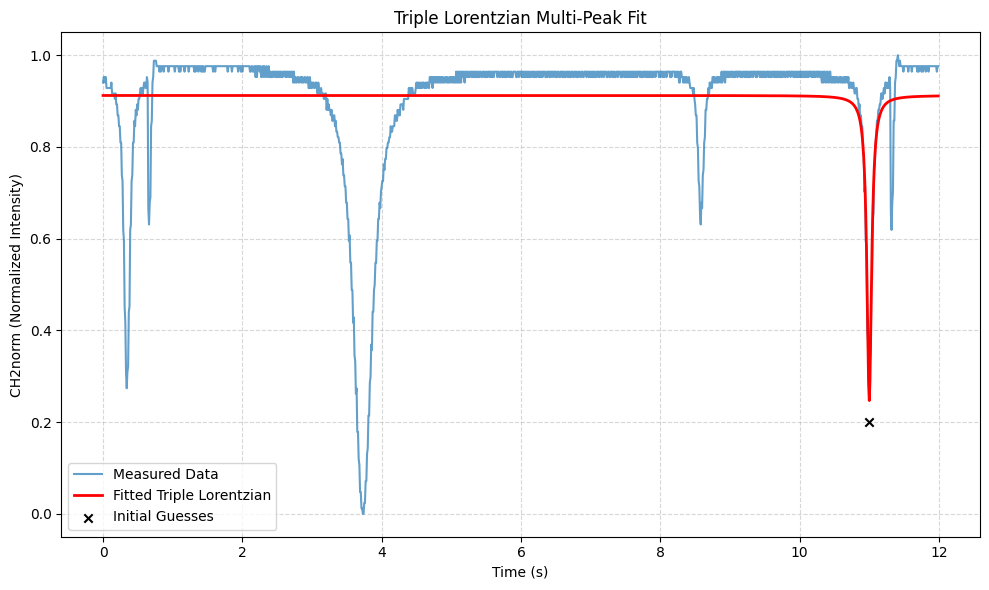

Lorentzian peak 1: 1.0310 ± 0.0019


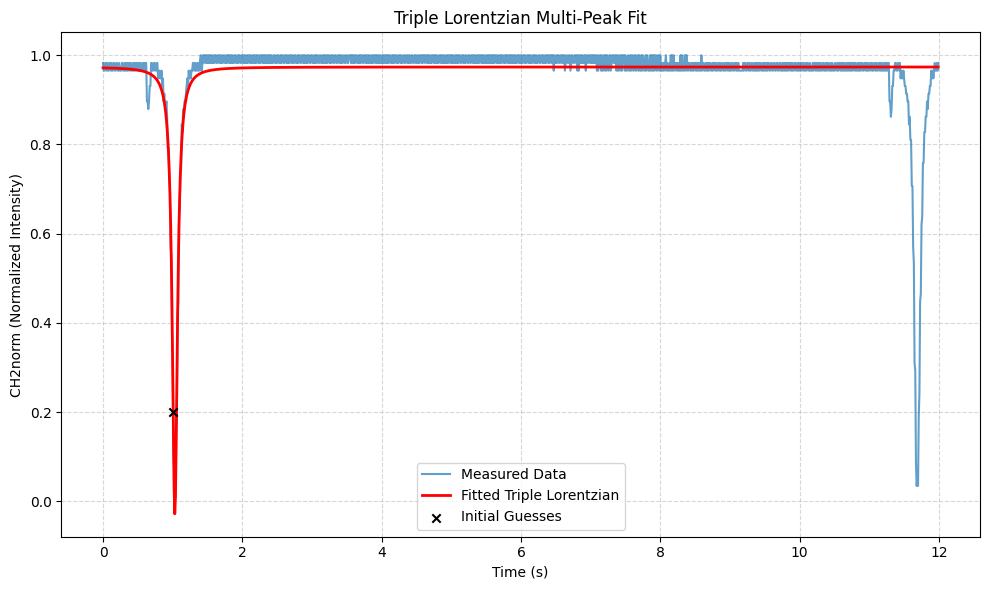

In [107]:
lopt = []
p0 = [[1.0,0.2,11.0,0.018],
      [1.0,0.2,1.0,0.018]]
for df_, p in zip(df, p0):
    fit_lorentzian(p, df_, lopt)

In [108]:
bfield = []
time = [10.9995, 1.0310]

def get_bfield_window(df, center_time, window_size=0.005):
    mask = (df['time'] >= center_time - window_size) & (df['time'] <= center_time + window_size)
    return df.loc[mask, 'Bfield'].mean()

for df_, t in zip(df, time):
    bfield.append(get_bfield_window(df_, t))
diff_field = bfield[0]-bfield[1]
VtoBoff = diff_field/33.3 #milivolts
VtoBoff

np.float64(1.6432432432432434e-06)

In [109]:
def quad_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3, a4, c4, w4):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    L4 = a4 / (1 + ((x - c4) / w4)**2)
    return y0 + L1 + L2 + L3 + L4

In [110]:
def hexa_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3, a4, c4, w4, a5, c5, w5, a6, c6, w6):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    L4 = a4 / (1 + ((x - c4) / w4)**2)
    L5 = a5 / (1 + ((x - c5) / w5)**2)
    L6 = a6 / (1 + ((x - c6) / w6)**2)
    return y0 + L1 + L2 + L3 + L4 + L5 + L6

In [111]:
def fit_4_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    # Ensure you have defined a function named quad_lorentzian
    popt, pcov = curve_fit(quad_lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    
    # Print centers for 4 peaks (indices 2, 5, 8, 11)
    for i in range(4):
        idx = i * 3 + 2
        print(f"Lorentzian peak {i+1}: {popt[idx]:.4f} ± {perr[idx]:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, quad_lorentzian(x_data, *popt), 'r-', 
             linewidth=2, label='Fitted Quad Lorentzian')
    
    # Plot initial guesses for centers (indices 2, 5, 8, 11) and amplitudes (1, 4, 7, 10)
    guess_centers = [p0[i*3 + 2] for i in range(4)]
    guess_amps = [p0[i*3 + 1] for i in range(4)]
    plt.scatter(guess_centers, guess_amps, color='black', marker='x', label='Initial Guesses', zorder=5)
    
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm')
    plt.title('Quad Lorentzian Multi-Peak Fit')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    # Appending centers to result list
    result_list.append([popt[2], popt[5], popt[8], popt[11]])
    return popt, perr

In [112]:
def fit_6_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    popt, pcov = curve_fit(hexa_lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    
    for i in range(6):
        idx = i * 3 + 2
        print(f"Lorentzian peak {i+1}: {popt[idx]:.4f} ± {perr[idx]:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, hexa_lorentzian(x_data, *popt), 'g-', 
             linewidth=2, label='Fitted Hexa Lorentzian')
    
    guess_centers = [p0[i*3 + 2] for i in range(6)]
    guess_amps = [p0[i*3 + 1] for i in range(6)]
    plt.scatter(guess_centers, guess_amps, color='black', marker='x', label='Initial Guesses')
    
    plt.title('Hexa Lorentzian Multi-Peak Fit')
    plt.legend(loc='best')
    plt.show()
    
    result_list.append([popt[i*3 + 2] for i in range(6)])
    return popt, perr

In [113]:
import glob

# Get all CSV files in quadratic_zeeman_data folder, excluding _B files (already processed outputs)
csv_files = sorted([f for f in glob.glob("quadratic_zeeman_data/*.csv") if not f.endswith("_B.csv")])

# Function to convert filename to variable name
def filename_to_varname(filepath):
    # Extract filename without extension
    filename = os.path.basename(filepath).replace(".csv", "")
    # Replace MHz/mHz/kHz with appropriate abbreviations
    varname = filename.replace("MHz", "mhz").replace("mHz", "mhz").replace("kHz", "khz")
    # Replace periods with 'p'
    varname = varname.replace(".", "p").replace("-", "_")
    # Lowercase and add df_ prefix
    varname = f"df_{varname.lower()}"
    return varname

# Create dataframes for all files
dataframes = {}
for filepath in csv_files:
    varname = filename_to_varname(filepath)
    # Determine time constant (using 10s for 10s files, 5s for 5s files)
    df_temp = add_magnetic_field(filepath)
    dataframes[varname] = df_temp
    print(f"{varname}: {filepath}")

# Make dataframes accessible as individual variables
for varname, df_temp in dataframes.items():
    globals()[varname] = df_temp

# Create a list of all dataframes
df = list(dataframes.values())

print(f"\nCreated {len(dataframes)} dataframes")
print(f"Access them via: all_dataframes (list) or individual variable names (e.g., df_10p8mhz_10s)")

Time constant extracted: 0.01
New file: quadratic_zeeman_data\10p8MHz_10s_B.csv
df_10p8mhz_10s: quadratic_zeeman_data\10p8MHz_10s.csv
Time constant extracted: 0.01
New file: quadratic_zeeman_data\13p4MHz_10s_1100_B.csv
df_13p4mhz_10s_1100: quadratic_zeeman_data\13p4MHz_10s_1100.csv
Time constant extracted: 0.005
New file: quadratic_zeeman_data\1p5mHz_5s_110_B.csv
df_1p5mhz_5s_110: quadratic_zeeman_data\1p5mHz_5s_110.csv
Time constant extracted: 0.005
New file: quadratic_zeeman_data\1p5mHz_5s_172_B.csv
df_1p5mhz_5s_172: quadratic_zeeman_data\1p5mHz_5s_172.csv
Time constant extracted: 0.005
New file: quadratic_zeeman_data\2mHz_5s_110_B.csv
df_2mhz_5s_110: quadratic_zeeman_data\2mHz_5s_110.csv
Time constant extracted: 0.005
New file: quadratic_zeeman_data\2mHz_5s_75_B.csv
df_2mhz_5s_75: quadratic_zeeman_data\2mHz_5s_75.csv
Time constant extracted: 0.005
New file: quadratic_zeeman_data\2p1mHz_5s_164_B.csv
df_2p1mhz_5s_164: quadratic_zeeman_data\2p1mHz_5s_164.csv
Time constant extracted: 0.